In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


In [16]:
df = pd.read_csv("insurance.csv")
df.head(2)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523


In [17]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [18]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [19]:
one_encode = OneHotEncoder(sparse_output=False)

new1 = one_encode.fit_transform(df[['sex']])
new1 = pd.DataFrame(
    new1,
    columns=one_encode.get_feature_names_out()
)

new = one_encode.fit_transform(df[['region']])
new = pd.DataFrame(
    new,
    columns=one_encode.get_feature_names_out()
)

new3 = pd.concat([new, new1], axis=1)

In [20]:
ord_encode = OrdinalEncoder(categories=[['no','yes']])
m = ord_encode.fit_transform(df[['smoker']])
m1 = pd.DataFrame(m,columns=ord_encode.get_feature_names_out())
m1

,smoker
0,1.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
1333,0.0
1334,0.0
1335,0.0
1336,0.0


In [21]:
df = df.drop(columns=['sex','region','smoker'])
df = pd.concat([new3,df,m1],axis=1)
df.head(2)

,region_northeast,region_northwest,region_southeast,region_southwest,sex_female,sex_male,age,bmi,children,charges,smoker
0,0.0,0.0,0.0,1.0,1.0,0.0,19,27.90,0,16884.9240,1.0
1,0.0,0.0,1.0,0.0,0.0,1.0,18,33.77,1,1725.5523,0.0


In [22]:
x = df.drop(columns=['charges'])
y = df['charges']

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.20,random_state=42)

In [24]:
lr = LinearRegression()
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [25]:
y_pred = lr.predict(x_test)
r2_score(y_test,y_pred)

0.7835929767120722

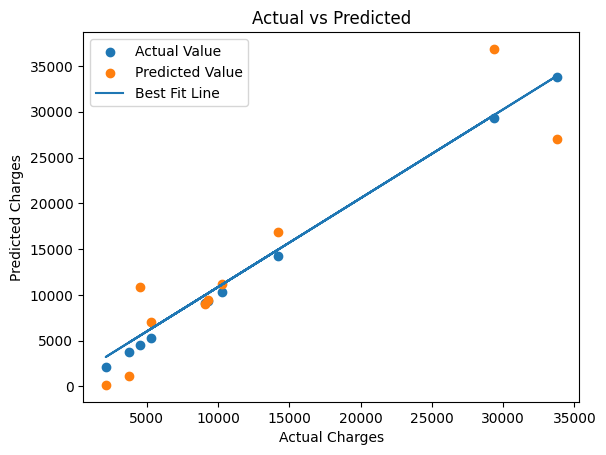

In [34]:
import matplotlib.pyplot as plt
import numpy as np

x = y_test.head(10).values
y = y_pred[:10]

m, c = np.polyfit(x, y, 1)

plt.scatter(x, x, label="Actual Value")
plt.scatter(x, y, label="Predicted Value")
plt.plot(x, m*x + c, label="Best Fit Line")

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()

In [27]:
residual = y_test - y_pred
residual.head()

764      125.517976
887    -1796.571643
890    -7527.427762
1293    -152.784951
259     6777.118343
Name: charges, dtype: float64

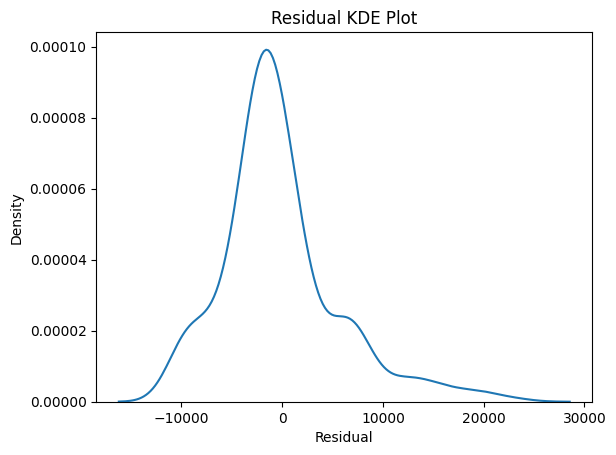

In [28]:
sns.kdeplot(residual)
plt.xlabel("Residual")
plt.ylabel("Density")
plt.title("Residual KDE Plot")
plt.show()